In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style="whitegrid")

df = pd.read_csv("telco_churn.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Check data types and missing values
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATS ===")
df.describe()

=== DATA TYPES ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== MISSING VALUES ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


No     73.5
Yes    26.5
Name: Churn, dtype: float64


<ipython-input-3-1a5aac228291>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])


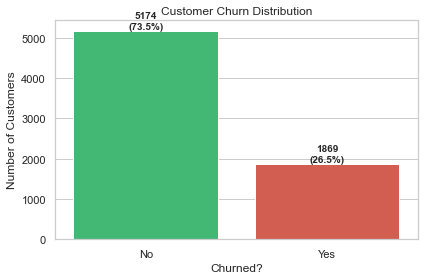

In [3]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(churn_pct.round(1))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn Distribution')
plt.xlabel('Churned?')
plt.ylabel('Number of Customers')

for i, count in enumerate(churn_counts):
    plt.text(i, count + 50, f'{count}\n({churn_pct.iloc[i]:.1f}%)', 
             ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()

<Figure size 576x360 with 0 Axes>

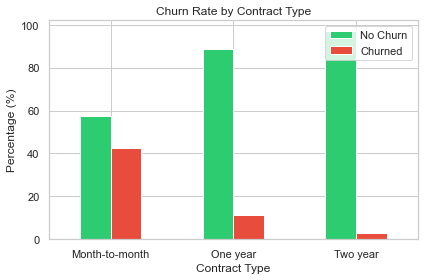

In [4]:
plt.figure(figsize=(8, 5))
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100

contract_churn.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='white')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(['No Churn', 'Churned'], loc='upper right')
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150)
plt.show()

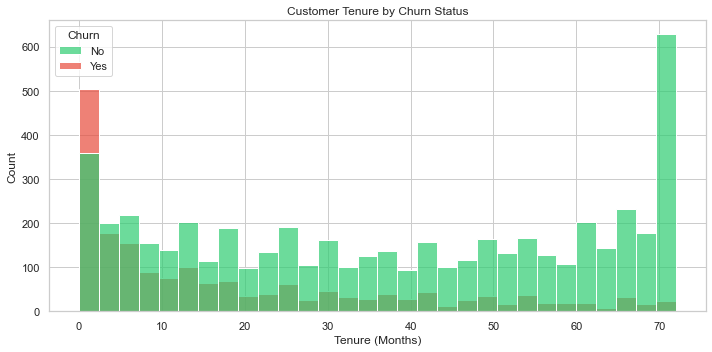

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, 
             palette=['#2ecc71', '#e74c3c'], alpha=0.7)
plt.title('Customer Tenure by Churn Status')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('tenure_churn.png', dpi=150)
plt.show()

<ipython-input-6-99240a7664c9>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges',


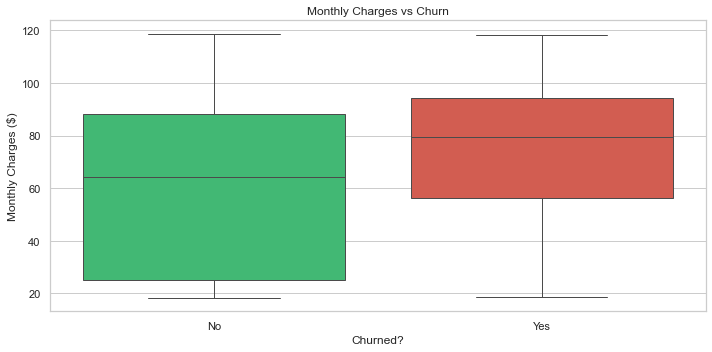

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


In [6]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', 
            palette=['#2ecc71', '#e74c3c'])
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churned?')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('charges_churn.png', dpi=150)
plt.show()

# Print the actual averages
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

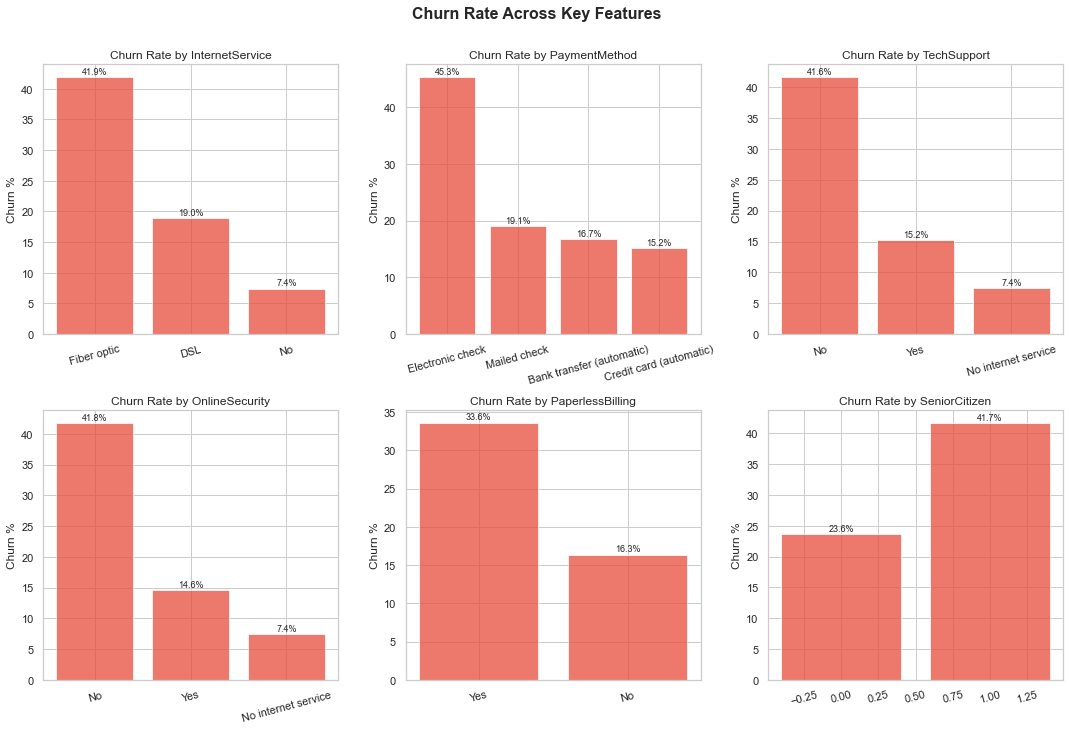

In [7]:
# Churn rate across multiple categories at once
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

categories = ['InternetService', 'PaymentMethod', 
              'TechSupport', 'OnlineSecurity', 
              'PaperlessBilling', 'SeniorCitizen']

for ax, col in zip(axes.flatten(), categories):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)
    
    bars = ax.bar(churn_rate.index, churn_rate.values, 
                  color='#e74c3c', alpha=0.75, edgecolor='white')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn %')
    ax.tick_params(axis='x', rotation=15)
    
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, 
                bar.get_height() + 0.5, 
                f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Churn Rate Across Key Features', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('churn_heatmap.png', dpi=150)
plt.show()

# Insights

26% of customers churned. That means 1 in 4 customers is leaving — a massive revenue problem worth solving.

Month-to-month customers churn at ~42%. Two-year contract customers churn at under 3%. The business should aggressively push customers toward longer contracts or offer incentives at the month-to-month stage.

Customers who churn almost all do so within the first year. This tells us where to focus retention efforts — early onboarding experience is critical.

Churned customers paid ~$74/month on average vs $61 for loyal customers. Customers on expensive plans with no loyalty perks are the most at risk.

Customers without online security or tech support churn at nearly double the rate of those who have it. These add-on services are actually retention tools in disguise.


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Nulls created:", df['TotalCharges'].isnull().sum())

df = df.dropna(subset=['TotalCharges'])
print("Clean shape:", df.shape)

Nulls created: 0
Clean shape: (7032, 21)
